In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, mannwhitneyu

[Swap(5), Swap(4), Swap(3), Swap(2), Swap(1)]

[Swap(1), Swap(2), Swap(3), Swap(4), Swap(5)]

In [3]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [4]:
# Deterministic
filename = 'FX_values_3_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]

# Stochastic
filename = 'FX_values_3_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]

## Deterministic

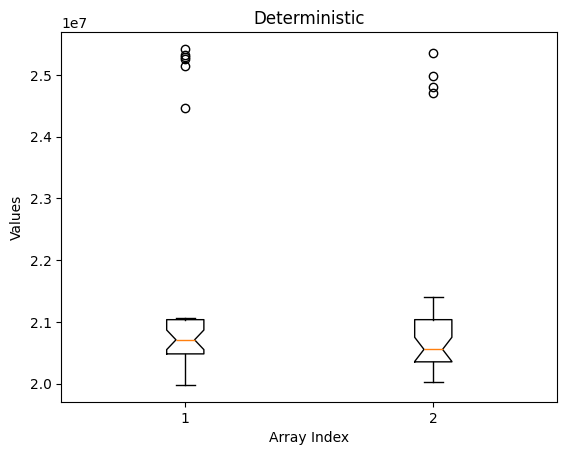

In [5]:
filename = 'FX_values_3_0.npz'
plot_boxplots(filename, "Deterministic")

In [7]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a0))
print(shapiro(b0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.645908292691253, pvalue=2.785806229654481e-07)
ShapiroResult(statistic=0.6253359429129932, pvalue=1.5093519933817566e-07)


In [8]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=503.0, pvalue=0.43764133504824576)


There's no significant difference between a and b.

## Stochastic

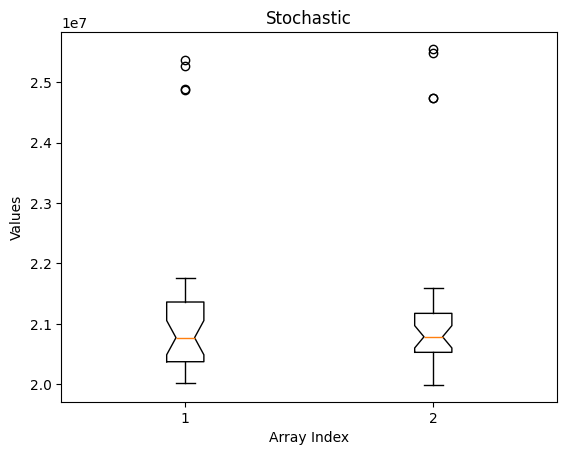

In [9]:
filename = 'FX_values_3_1.npz'
plot_boxplots(filename, "Stochastic")

In [10]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a1))
print(shapiro(b1))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.6787741257319035, pvalue=7.773045144127095e-07)
ShapiroResult(statistic=0.645910300290867, pvalue=2.785975794948523e-07)


In [11]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a1, b1, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=423.0, pvalue=0.6952153990669099)


There's no significant difference between a and b.

# Deterministic x Stochastic

In [12]:
print(f"a0 vs a1: {mannwhitneyu(a0, a1, alternative='two-sided')}")
print(f"b0 vs b1: {mannwhitneyu(b0, b1, alternative='two-sided')}")

a0 vs a1: MannwhitneyuResult(statistic=450.0, pvalue=1.0)
b0 vs b1: MannwhitneyuResult(statistic=360.0, pvalue=0.18576685629821565)


No difference.